# Correlation evaluation (5.4)

- Load **real** (`..._zscaled.csv`) and **synthetic** (`..._CVAE1-1_generated.csv`) using **chunked** `read_csv`.
- **Step 1:** Pearson $r$ on real — pairwise labels (**Positive** / **Negative** / **Neutral** with $|r|\le 0.3$ as neutral).
- **Step 2:** Pearson $r$ on synthetic (no header; columns aligned to real).
- **Summary 1 (Chunks 1–3):** global and stratified agreement; false-correlation rate on real-Neutral pairs.
- **Summary 2:** quantile bins on real; per-pair score = **1 − L1** on normalized joint tables ( **1** = identical; paper Eq. (3) uses an extra **1/2**); `acc_bivariate`; overall / stratified means; **Chunk C:** histograms (global + Pos/Neg/Neu).


In [18]:
from pathlib import Path

import numpy as np
import pandas as pd

# --- paths (same folder as this notebook) ---
BASE = Path(r"d:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28")
REAL_PATH = BASE / "processed_train_136_full_model_data_yj_transformed_zscaled.csv"
SYN_PATH = (
    BASE
    / "processed_train_136_full_model_data_yj_transformed_zscaled_epochES_batch01_CVAE1-1_generated.csv"
)

# Pearson r label rule: neutral includes boundaries ±0.3
RHO_THRESH = 0.3
CHUNK_ROWS = 128  # CSV row chunks (adjust if I/O or memory needs change)


def _feature_columns_from_real_csv(path: Path) -> list[str]:
    header = pd.read_csv(path, nrows=0)
    cols = list(header.columns)
    if "groups" in cols:
        cols = [c for c in cols if c != "groups"]
    return cols


FEATURE_COLS = _feature_columns_from_real_csv(REAL_PATH)


def load_real_chunked(path: Path, feature_cols: list[str], chunk_rows: int) -> pd.DataFrame:
    """Stack row-chunks of the real table (numeric features only, no 'groups')."""
    parts: list[pd.DataFrame] = []
    for chunk in pd.read_csv(
        path,
        usecols=feature_cols,
        chunksize=chunk_rows,
        low_memory=False,
    ):
        parts.append(chunk)
    return pd.concat(parts, axis=0, ignore_index=True)


def load_syn_chunked(path: Path, feature_cols: list[str], chunk_rows: int) -> pd.DataFrame:
    """Synthetic file has no header: first len(feature_cols) columns aligned to real feature names."""
    nfeat = len(feature_cols)
    parts: list[pd.DataFrame] = []
    for chunk in pd.read_csv(
        path,
        header=None,
        names=feature_cols,
        usecols=range(nfeat),
        chunksize=chunk_rows,
        low_memory=False,
    ):
        parts.append(chunk)
    return pd.concat(parts, axis=0, ignore_index=True)


df_real = load_real_chunked(REAL_PATH, FEATURE_COLS, CHUNK_ROWS)
df_syn = load_syn_chunked(SYN_PATH, FEATURE_COLS, CHUNK_ROWS)

print("features:", len(FEATURE_COLS))
print("df_real:", df_real.shape, "| df_syn:", df_syn.shape)

features: 144
df_real: (604, 144) | df_syn: (1000, 144)


In [19]:
# --- Step 1: Pearson on REAL only; fixed pairwise labels (upper triangle, no diagonal) ---

corr_real = df_real.corr(method="pearson", numeric_only=True)

cols = corr_real.columns.to_numpy()
R = corr_real.to_numpy(dtype=np.float64)
ii, jj = np.triu_indices(len(cols), k=1)
rho = R[ii, jj]

label = np.where(
    rho > RHO_THRESH,
    "Positive",
    np.where(rho < -RHO_THRESH, "Negative", "Neutral"),
)

# `rho_real` / `rho_syn` columns store Pearson r (name kept for downstream cells).
pairwise_labels = pd.DataFrame(
    {
        "feature_i": cols[ii],
        "feature_j": cols[jj],
        "rho_real": rho,
        "label_real": label,
    }
)

n_pairs = len(pairwise_labels)
print("pairwise rows (unordered):", n_pairs, "| expected C(n,2):", len(FEATURE_COLS) * (len(FEATURE_COLS) - 1) // 2)
print("\nlabel_real counts:")
print(pairwise_labels["label_real"].value_counts())


pairwise rows (unordered): 10296 | expected C(n,2): 10296

label_real counts:
label_real
Neutral     6370
Positive    2437
Negative    1489
Name: count, dtype: int64


In [20]:
# --- Step 2: Pearson on GENERATED (`df_syn` columns match real feature order) ---

corr_syn = df_syn.corr(method="pearson", numeric_only=True)

# Align columns to real (same names/order as `corr_real`)
missing = [c for c in corr_real.columns if c not in corr_syn.columns]
extra = [c for c in corr_syn.columns if c not in corr_real.columns]
if missing or extra:
    raise ValueError(f"column mismatch: missing={missing[:5]}... extra={extra[:5]}...")

corr_syn = corr_syn.reindex(index=corr_real.columns, columns=corr_real.columns)

ii, jj = np.triu_indices(len(corr_real.columns), k=1)
R_syn = corr_syn.to_numpy(dtype=np.float64)
rho_syn = R_syn[ii, jj]

pairwise_labels["rho_syn"] = rho_syn
pairwise_labels["label_syn"] = np.where(
    rho_syn > RHO_THRESH,
    "Positive",
    np.where(rho_syn < -RHO_THRESH, "Negative", "Neutral"),
)

print("corr_syn shape:", corr_syn.shape)
print("\nlabel_syn counts:")
print(pairwise_labels["label_syn"].value_counts())


corr_syn shape: (144, 144)

label_syn counts:
label_syn
Neutral     5946
Positive    2713
Negative    1637
Name: count, dtype: int64


### Summary 1 — Chunk 1: Global class + sign agreement

For each unordered pair, the **real-data** label is $L^{(r)} \in \{\mathrm{Pos},\mathrm{Neg},\mathrm{Neu}\}$ from **Pearson** $r$, with threshold $\tau=0.3$: **Neutral** iff $|r_{\mathrm{real}}|\le \tau$.

**Agreement indicator** $A\in\{0,1\}$ per pair:

- If $L^{(r)}=\mathrm{Neu}$: $A=1$ iff $|r_{\mathrm{syn}}|\le \tau$.
- If $L^{(r)}\in\{\mathrm{Pos},\mathrm{Neg}\}$: $A=1$ iff $L^{(\mathrm{syn})}=L^{(r)}$ and $\mathrm{sign}(r_{\mathrm{syn}})=\mathrm{sign}(r_{\mathrm{real}})$.

**Global rate** over all $N=\binom{D}{2}$ unordered pairs:

$$
R_{\mathrm{global}}=\frac{1}{N}\sum_{\mathrm{pairs}} A.
$$

In [21]:
# Chunk 1 — global agreement (requires pairwise_labels from Step 2)

rr = pairwise_labels["rho_real"].to_numpy()
rs = pairwise_labels["rho_syn"].to_numpy()
lr = pairwise_labels["label_real"].to_numpy()
ls = pairwise_labels["label_syn"].to_numpy()

tau = RHO_THRESH
neutral_real = lr == "Neutral"
same_sign = np.sign(rr) == np.sign(rs)
same_label = lr == ls

agree = np.where(
    neutral_real,
    np.abs(rs) <= tau,
    (~neutral_real) & same_label & same_sign,
)

N = len(pairwise_labels)
R_global = float(agree.mean())

print(f"N (all unordered pairs) = {N}")
print(f"R_global = {R_global:.6f}  ({agree.sum()} / {N})")

N (all unordered pairs) = 10296
R_global = 0.938423  (9662 / 10296)


### Summary 1 — Chunk 2: Conditional agreement (stratified by real label)

Fix $k \in \{\mathrm{Pos},\mathrm{Neg},\mathrm{Neu}\}$. Let $\mathcal{P}_k = \{\text{pairs}: L^{(r)}=k\}$ and $N_k = |\mathcal{P}_k|$.

$$
R_k=\frac{1}{N_k}\sum_{(i,j)\in\mathcal{P}_k} A_{ij}.
$$

Same $A_{ij}$ as Chunk 1. The three $R_k$ have **different denominators**; they are not three shares that sum to 1 with $R_{\mathrm{global}}$.

In [22]:
# Chunk 2 — conditional rates by real label (uses `agree` from Chunk 1)

rows = []
for k, name in [("Positive", "R_Pos"), ("Negative", "R_Neg"), ("Neutral", "R_Neu")]:
    m = lr == k
    nk = int(m.sum())
    rk = float(agree[m].mean()) if nk else float("nan")
    rows.append({"real_label": k, "symbol": name, "N_k": nk, "R_k": rk})

summary_stratified = pd.DataFrame(rows)
print(summary_stratified.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

real_label symbol  N_k      R_k
  Positive  R_Pos 2437 0.989741
  Negative  R_Neg 1489 0.946273
   Neutral  R_Neu 6370 0.916954


### Summary 1 — Chunk 3: False-correlation rate (Neutral subset)

Restrict to real-Neutral pairs $\mathcal{P}_{\mathrm{Neu}}=\{|r_{\mathrm{real}}|\le \tau\}$ (Pearson) with $N_{\mathrm{Neu}}=|\mathcal{P}_{\mathrm{Neu}}|$.

$$
F_{\mathrm{false}}=\frac{1}{N_{\mathrm{Neu}}}\sum_{(i,j)\in\mathcal{P}_{\mathrm{Neu}}} \mathbf{1}\big(|r_{\mathrm{syn}}|>\tau\big).
$$

Link to Chunk 2: $R_{\mathrm{Neu}} = 1 - F_{\mathrm{false}}$ (same subset and $\tau$; "stay neutral" vs "cross out of band" are complements).

In [23]:
# Chunk 3 — false-correlation / boundary-crossing rate on real-Neutral pairs

m_neu = lr == "Neutral"
N_neu = int(m_neu.sum())
cross = (np.abs(rs) > tau) & m_neu
F_false = float(cross.sum() / N_neu) if N_neu else float("nan")
R_neu_from_chunk2 = float(agree[m_neu].mean()) if N_neu else float("nan")

print(f"N_Neu = {N_neu}")
print(f"F_false (|r_syn| > tau among real-Neu) = {F_false:.6f}  ({int(cross.sum())} / {N_neu})")
print(f"1 - F_false = {1.0 - F_false:.6f}  (should match R_Neu from Chunk 2: {R_neu_from_chunk2:.6f})")

N_Neu = 6370
F_false (|r_syn| > tau among real-Neu) = 0.083046  (529 / 6370)
1 - F_false = 0.916954  (should match R_Neu from Chunk 2: 0.916954)


### Summary 2 — Joint-table bivariate accuracy (L1 on normalized tables)

**Binning (training-only, automatic):** For each numeric column, fit **up to $K{=}10$** equal-frequency (**quantile**) bins on **real** data (`df_real`); apply the same binning to **synthetic** (`df_syn`). If a column has fewer than 10 distinct values, use fewer bins (down to 1 for constants). This matches the paper’s “deciles / at most ten levels” spirit for continuous features.

For unordered pair $(m,n)$, build **normalized** contingency tables $\mathbf{C}^{(m,n)}_{\mathrm{real}}$ and $\mathbf{C}^{(m,n)}_{\mathrm{syn}}$ (size $n_m \times n_n$, with $n_m,n_n \le 10$).

**Per-pair score** (paper Eq. (3) is $\tfrac{1}{2}(1-\sum|\Delta|)$; here we **drop the $\tfrac{1}{2}$** so identical tables give **1**):

$$
\mathrm{Acc}^{(m,n)} = 1 - \sum_{a,b} \bigl| \mathbf{C}^{(m,n)}_{\mathrm{real},ab} - \mathbf{C}^{(m,n)}_{\mathrm{syn},ab} \bigr|.
$$

**Overall** and **stratified** means (strata = real **Pearson** label $L^{(r)} \in \{\mathrm{Pos},\mathrm{Neg},\mathrm{Neu}\}$ from Summary 1):

$$
\overline{\mathrm{Acc}} = \frac{1}{N}\sum_{m<n}\mathrm{Acc}^{(m,n)},\qquad
\overline{\mathrm{Acc}}_{k} = \frac{1}{N_k}\sum_{m<n:\, L^{(r)}=k}\mathrm{Acc}^{(m,n)}.
$$

In [24]:
# Summary 2 — Chunk A: quantile binning on real (column chunks); map real & syn to bin indices

from sklearn.preprocessing import KBinsDiscretizer

D = len(FEATURE_COLS)
assert df_real.shape[1] == D == df_syn.shape[1]

bins_real = np.zeros((len(df_real), D), dtype=np.int16)
bins_syn = np.zeros((len(df_syn), D), dtype=np.int16)
n_bins_col = np.ones(D, dtype=np.int8)

COL_CHUNK = 24
MAX_BINS = 10

for c0 in range(0, D, COL_CHUNK):
    c1 = min(c0 + COL_CHUNK, D)
    for col_idx in range(c0, c1):
        col = FEATURE_COLS[col_idx]
        x_tr = df_real[col].to_numpy(dtype=np.float64, copy=False).reshape(-1, 1)
        x_sy = df_syn[col].to_numpy(dtype=np.float64, copy=False).reshape(-1, 1)
        nuniq = int(np.unique(x_tr).size)
        if nuniq <= 1:
            n_bins_col[col_idx] = 1
            continue
        n_bins_use = int(min(MAX_BINS, nuniq))
        try:
            est = KBinsDiscretizer(
                n_bins=n_bins_use,
                encode="ordinal",
                strategy="quantile",
                quantile_method="averaged_inverted_cdf",
                subsample=None,
            )
        except TypeError:
            est = KBinsDiscretizer(
                n_bins=n_bins_use,
                encode="ordinal",
                strategy="quantile",
                subsample=None,
            )
        est.fit(x_tr)
        k = int(est.n_bins_[0])
        n_bins_col[col_idx] = k
        br = est.transform(x_tr).ravel().astype(np.int16, copy=False)
        bs = est.transform(x_sy).ravel().astype(np.int16, copy=False)
        bs = np.clip(bs, 0, k - 1)
        bins_real[:, col_idx] = br
        bins_syn[:, col_idx] = bs
    print(f"columns fitted: {c1} / {D}")

print("n_bins_col (min / max):", int(n_bins_col.min()), int(n_bins_col.max()))

columns fitted: 24 / 144
columns fitted: 48 / 144
columns fitted: 72 / 144
columns fitted: 96 / 144
columns fitted: 120 / 144
columns fitted: 144 / 144
n_bins_col (min / max): 1 10


c:\Users\17376\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\preprocessing\_discre

In [25]:
# Summary 2 — Chunk B: per-pair joint-table accuracy (pair chunks) + overall & stratified means


def _pair_joint_acc(bi_r, bj_r, bi_s, bj_s, ni: int, nj: int) -> float:
    """Bivariate score = 1 - L1 diff of normalized joint tables (max 1 if identical)."""
    Hr = np.zeros((ni, nj), dtype=np.float64)
    Hs = np.zeros((ni, nj), dtype=np.float64)
    np.add.at(Hr, (bi_r.astype(np.int64, copy=False), bj_r.astype(np.int64, copy=False)), 1.0)
    np.add.at(Hs, (bi_s.astype(np.int64, copy=False), bj_s.astype(np.int64, copy=False)), 1.0)
    sr = Hr.sum()
    ss = Hs.sum()
    if sr <= 0 or ss <= 0:
        return float("nan")
    Hr /= sr
    Hs /= ss
    return float(1.0 - np.abs(Hr - Hs).sum())


ii2, jj2 = np.triu_indices(D, k=1)
n_pairs2 = ii2.shape[0]
assert n_pairs2 == len(pairwise_labels), "pair count must match pairwise_labels"

acc_pairwise = np.empty(n_pairs2, dtype=np.float64)
PAIR_CHUNK = 2048

for t0 in range(0, n_pairs2, PAIR_CHUNK):
    t1 = min(t0 + PAIR_CHUNK, n_pairs2)
    for t in range(t0, t1):
        i, j = int(ii2[t]), int(jj2[t])
        ni, nj = int(n_bins_col[i]), int(n_bins_col[j])
        acc_pairwise[t] = _pair_joint_acc(
            bins_real[:, i],
            bins_real[:, j],
            bins_syn[:, i],
            bins_syn[:, j],
            ni,
            nj,
        )
    print(f"pairs processed: {t1} / {n_pairs2}")

pairwise_labels["acc_bivariate"] = acc_pairwise

lr2 = pairwise_labels["label_real"].to_numpy()
acc_overall = float(np.nanmean(acc_pairwise))
print("\n--- Overall ---")
print(f"Acc_bar (all unordered pairs) = {acc_overall:.6f}  (N = {n_pairs2})")

rows_acc = []
for k in ("Positive", "Negative", "Neutral"):
    m = lr2 == k
    nk = int(m.sum())
    mean_k = float(np.nanmean(acc_pairwise[m])) if nk else float("nan")
    rows_acc.append({"real_label": k, "N_k": nk, "Acc_bar_k": mean_k})

summary_acc_stratified = pd.DataFrame(rows_acc)
print("\n--- Stratified by real Pearson label ---")
print(summary_acc_stratified.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

pairs processed: 2048 / 10296
pairs processed: 4096 / 10296
pairs processed: 6144 / 10296
pairs processed: 8192 / 10296
pairs processed: 10240 / 10296
pairs processed: 10296 / 10296

--- Overall ---
Acc_bar (all unordered pairs) = 0.596019  (N = 10296)

--- Stratified by real Pearson label ---
real_label  N_k  Acc_bar_k
  Positive 2437   0.597825
  Negative 1489   0.570878
   Neutral 6370   0.601204


### Summary 2 — Chunk C: Histograms of per-pair `acc_bivariate`

Distributions of $\mathrm{Acc}^{(m,n)} = 1 - \sum_{a,b}|C^{\mathrm{real}}_{ab} - C^{\mathrm{syn}}_{ab}|$ for **all pairs** and separately for pairs whose **real** Pearson label is Positive, Negative, or Neutral. Vertical dashed line: subset mean.

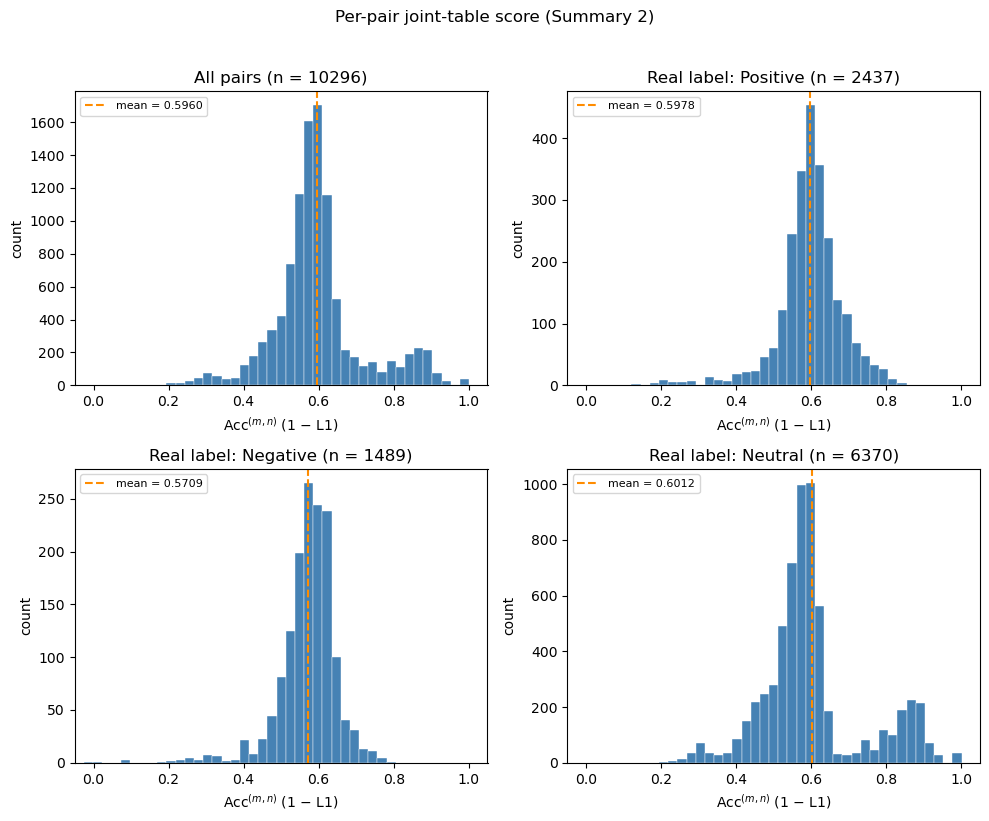

In [26]:
# Summary 2 — Chunk C: histograms (global + three real-label strata)

import matplotlib.pyplot as plt

acc_col = pairwise_labels["acc_bivariate"].to_numpy()
lab_col = pairwise_labels["label_real"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)
panels = [
    (axes[0, 0], "All pairs", acc_col),
    (axes[0, 1], "Real label: Positive", acc_col[lab_col == "Positive"]),
    (axes[1, 0], "Real label: Negative", acc_col[lab_col == "Negative"]),
    (axes[1, 1], "Real label: Neutral", acc_col[lab_col == "Neutral"]),
]

bin_edges = np.linspace(-0.05, 1.05, 46)

for ax, title, vals in panels:
    v = vals[np.isfinite(vals)]
    ax.hist(v, bins=bin_edges, color="steelblue", edgecolor="white", linewidth=0.3)
    if len(v):
        ax.axvline(float(np.mean(v)), color="darkorange", linestyle="--", linewidth=1.5, label=f"mean = {np.mean(v):.4f}")
    ax.set_title(f"{title} (n = {len(v)})")
    ax.set_xlabel(r"$\mathrm{Acc}^{(m,n)}$ (1 − L1)")
    ax.set_ylabel("count")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xlim(-0.05, 1.05)

plt.suptitle("Per-pair joint-table score (Summary 2)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()